# 0. Librerías y generalización de rutas

In [92]:
from pathlib import Path
import time, unicodedata, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from cycler import cycler
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
SEED = 42
np.random.seed(SEED)
warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW, PROC, FIG = ROOT / "data" / "raw", ROOT / "data" / "processed", ROOT / "reports" / "figuras"
for p in (RAW, PROC, FIG):
    p.mkdir(parents=True, exist_ok=True)

ESTUDIO = {"Mazurén": "mazuren", "Modelia": "modelia", "Terreros": "terreros"}     # nombre -> texto a buscar (sin tilde)
FESTIVOS = pd.to_datetime(["2026-08-07", "2026-08-17"])                             # festivos de agosto de 2026

# Estilo común de las gráficas
AZUL, NARANJA, VERDE, GRIS, TINTA = "#2a78d6", "#eb6834", "#1baf7a", "#b9b8b2", "#52514e"
COLOR_DIA = {"habil": AZUL, "sabado": NARANJA, "domingo_festivo": VERDE}
NOMBRE_DIA = {"habil": "Día hábil", "sabado": "Sábado", "domingo_festivo": "Domingo o festivo"}
COLOR_EST = dict(zip(ESTUDIO, [AZUL, NARANJA, VERDE]))
DIAS = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
MAPA_AZUL = LinearSegmentedColormap.from_list("azul", ["#fcfcfb", "#cde2fb", "#6da7ec", "#2a78d6", "#0d366b"])

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": GRIS,
    "axes.grid": True, "grid.color": "#e7e6e2", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "lines.linewidth": 2, "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelcolor": TINTA, "xtick.color": TINTA, "ytick.color": TINTA, "legend.frameon": False,
    "axes.prop_cycle": cycler(color=[AZUL, NARANJA, VERDE, "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"])})

def eje_horas(ax):
    ax.set_xticks(range(4, 24, 4)); ax.set_xticklabels([f"{h:02d}:00" for h in range(4, 24, 4)])
    ax.set_xlabel("Hora del día")

def miles(x, _=None):
    return f"{x / 1000:,.0f} mil".replace(",", ".") if abs(x) >= 1000 else f"{x:,.0f}"

def sin_tilde(s):                                   # "MAZURÉN" -> "mazuren"
    return unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode().lower()

def a_hora(v):                                      # "05:15" -> 5.25
    h, m = str(v).split(":")[:2]
    return int(h[-2:]) + int(m) / 60

# 1. Problema y datos

**Pregunta.** ¿Cuántas validaciones (entradas con tarjeta TuLlave) tendrá una estación troncal de
TransMilenio en cada franja de 15 minutos, conociendo la estación, la troncal, la hora y el tipo de día?

**A quién le sirve.** A TransMilenio S.A. y a los operadores: saber con anticipación cuánta gente
entra a cada estación en cada franja permite programar buses y personal de taquilla y seguridad.

| | |
|---|---|
| **Fuente** | Validaciones troncales por intervalos de 15 minutos, TransMilenio S.A., publicadas en Datos Abiertos Bogotá: https://storage.googleapis.com/validaciones_tmsa/validaciones_mensuales.html (licencia CC BY-SA 4.0) |
| **Periodo** | Agosto de 2026 (31 días). Archivo descargado el 2 de Octubre |
| **Tamaño** | 294.004 registros: 123 estaciones por 31 días por unas 77 franjas diarias |
| **Variable objetivo** | `validaciones`: entradas a la estación en la franja de 15 minutos (numérica) |
| **Variables explicativas** | `estación`, `linea` (troncal), `intervalo` (franja), `fecha` y `tipo_dia` (hábil, sábado, domingo o festivo) |

El archivo original viene en formato ancho (una columna por día y una fila por acceso de estación).
Se pasa a formato largo y se suman los accesos de cada estación.

In [93]:
import pandas as pd

# 1. Leer el Excel
df = pd.read_excel(RAW/"Validaciones_Agosto.xlsx")

# 2. Eliminar las filas donde Fase = "Dual"
df = df[df["Fase"] != "Dual"].copy()

# 3. Identificar las columnas de fechas usando iloc
#    Las fechas están desde la columna 6 hasta la 36
columnas_fecha = df.columns[5:36]

# 4. Pasar de formato ancho a formato largo
#
#    Cada registro original se convierte en 31 registros:
#    uno por cada día de agosto.
data = df.melt(
    id_vars=["Línea", "Estación", "Intervalo"],
    value_vars=columnas_fecha,
    var_name="Fecha",
    value_name="Validaciones"
)

# 5. Convertir Fecha a datetime
data["Fecha"] = pd.to_datetime(data["Fecha"])

# 6. Sumar las validaciones agrupando por:
#    Línea, Estación, Intervalo y Fecha
data = (
    data
    .groupby(
        ["Línea", "Estación", "Intervalo", "Fecha"],
        as_index=False
    )["Validaciones"]
    .sum()
)

# 7. Ordenar el resultado
data = data.sort_values(
    ["Línea", "Estación", "Fecha", "Intervalo"]
).reset_index(drop=True)

# 8. Verificar resultado
print(data.head())

                  Línea         Estación Intervalo      Fecha  Validaciones
0  (11) Zona K Calle 26  (06001) Modelia  04:15:00 2026-08-01             0
1  (11) Zona K Calle 26  (06001) Modelia  04:30:00 2026-08-01             0
2  (11) Zona K Calle 26  (06001) Modelia  04:45:00 2026-08-01             3
3  (11) Zona K Calle 26  (06001) Modelia  05:00:00 2026-08-01             6
4  (11) Zona K Calle 26  (06001) Modelia  05:15:00 2026-08-01            12


In [94]:
import numpy as np

data = data.rename(columns={"Línea": "linea", "Estación": "estación", "Intervalo": "intervalo",
                            "Fecha": "fecha", "Validaciones": "validaciones"})

FESTIVOS = pd.to_datetime(["2026-08-07", "2026-08-17"])        # festivos de agosto de 2026
dia = data["fecha"].dt.dayofweek
data["tipo_dia"] = np.select([data["fecha"].isin(FESTIVOS) | (dia == 6), dia == 5],
                             ["domingo_festivo", "sabado"], "habil")

print(data.shape, "| Estaciones:", data["estación"].nunique())
print(data.groupby("tipo_dia")["fecha"].nunique())

(294004, 6) | Estaciones: 123
tipo_dia
domingo_festivo     7
habil              19
sabado              5
Name: fecha, dtype: int64


# 2. Análisis exploratorio

Antes de modelar se revisa la calidad de los datos, cómo se distribuye la variable a predecir y cómo
cambia con cada variable explicativa. Es un análisis descriptivo: no se usa para escoger hiperparámetros.

## 2.1 Calidad de los datos

Registros: 294,004 | Estaciones: 123 | Troncales: 14 | Días: 31 (del 2026-08-01 al 2026-08-31)
Validaciones en total: 31,016,651

Nulos por columna: {'linea': 0, 'estación': 0, 'intervalo': 0, 'fecha': 0, 'validaciones': 0, 'tipo_dia': 0, 'hora': 0, 'dia_semana': 0}
Registros repetidos (misma estación, fecha y franja): 0
Validaciones negativas: 0

Franjas por estación y día: mínimo 1, mediana 79, máximo 87
Registros por estación: mínimo 31, máximo 2,697
Estaciones que aparecen en más de una troncal: 0

Registros en cero: 7.8% del total | entre 5:00 y 21:00: 2.3%


,count,mean,std,min,25%,50%,75%,90%,99%,max
validaciones,294004.0,105.5,217.1,0.0,14.0,46.0,108.0,240.0,1022.0,4687.0


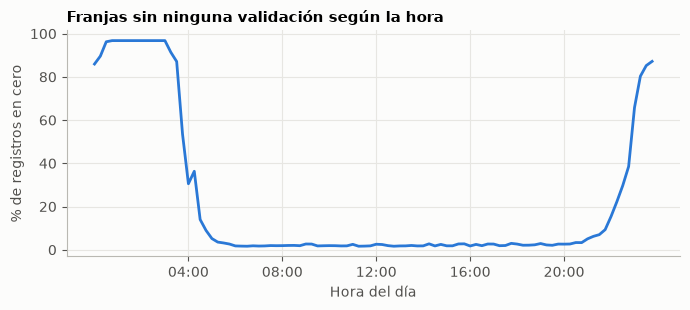

In [95]:
data["hora"] = data["intervalo"].map(a_hora)
data["dia_semana"] = data["fecha"].dt.dayofweek
est_norm = data["estación"].map(sin_tilde)
NOMBRE_EST = {corto: data.loc[est_norm.str.contains(buscar), "estación"].iloc[0] for corto, buscar in ESTUDIO.items()}

llave = ["estación", "fecha", "intervalo"]
print(f"Registros: {len(data):,} | Estaciones: {data['estación'].nunique()} | Troncales: {data['linea'].nunique()}"
      f" | Días: {data['fecha'].nunique()} (del {data['fecha'].min().date()} al {data['fecha'].max().date()})")
print(f"Validaciones en total: {data['validaciones'].sum():,.0f}")
print("\nNulos por columna:", data.isna().sum().to_dict())
print("Registros repetidos (misma estación, fecha y franja):", int(data.duplicated(llave).sum()))
print("Validaciones negativas:", int((data["validaciones"] < 0).sum()))

franjas = data.groupby(["estación", "fecha"]).size()
reg = data.groupby("estación").size()
print(f"\nFranjas por estación y día: mínimo {franjas.min()}, mediana {franjas.median():.0f}, máximo {franjas.max()}")
print(f"Registros por estación: mínimo {reg.min():,}, máximo {reg.max():,}")
print("Estaciones que aparecen en más de una troncal:", int((data.groupby("estación")["linea"].nunique() > 1).sum()))

cero = data["validaciones"] == 0
dia_op = data["hora"].between(5, 21)
print(f"\nRegistros en cero: {cero.mean():.1%} del total | entre 5:00 y 21:00: {cero[dia_op].mean():.1%}")
display(data["validaciones"].describe(percentiles=[.25, .5, .75, .9, .99]).round(1).to_frame().T)

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(cero.groupby(data["hora"]).mean() * 100, color=AZUL)
ax.set_ylabel("% de registros en cero"); eje_horas(ax)
ax.set_title("Franjas sin ninguna validación según la hora")
plt.tight_layout(); plt.savefig(FIG / "eda_ceros.png", dpi=120); plt.show()

## 2.2 Distribución de la variable a predecir

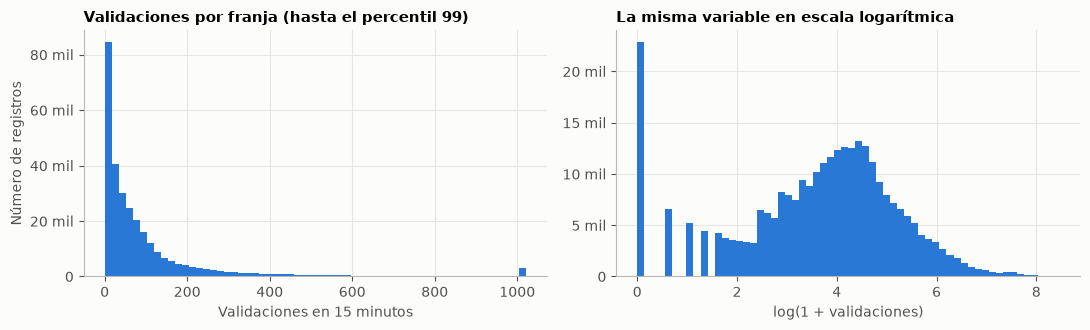

Media 105.5 | mediana 46 | desviación 217.1 | máximo 4,687
Asimetría: 6.98 en la escala original y -0.52 en logaritmo
El 10 % de los registros con más validaciones concentra el 52% del total


In [96]:
v = data["validaciones"]
fig, (a, b) = plt.subplots(1, 2, figsize=(11, 3.4))
a.hist(v.clip(upper=v.quantile(0.99)), bins=60, color=AZUL)
a.set_title("Validaciones por franja (hasta el percentil 99)")
a.set_xlabel("Validaciones en 15 minutos"); a.set_ylabel("Número de registros"); a.yaxis.set_major_formatter(miles)
b.hist(np.log1p(v), bins=60, color=AZUL)
b.set_title("La misma variable en escala logarítmica")
b.set_xlabel("log(1 + validaciones)"); b.yaxis.set_major_formatter(miles)
plt.tight_layout(); plt.savefig(FIG / "eda_distribucion.png", dpi=120); plt.show()

print(f"Media {v.mean():.1f} | mediana {v.median():.0f} | desviación {v.std():.1f} | máximo {v.max():,.0f}")
print(f"Asimetría: {v.skew():.2f} en la escala original y {np.log1p(v).skew():.2f} en logaritmo")
print(f"El 10 % de los registros con más validaciones concentra el {v[v >= v.quantile(0.9)].sum() / v.sum():.0%} del total")

## 2.3 Demanda día a día

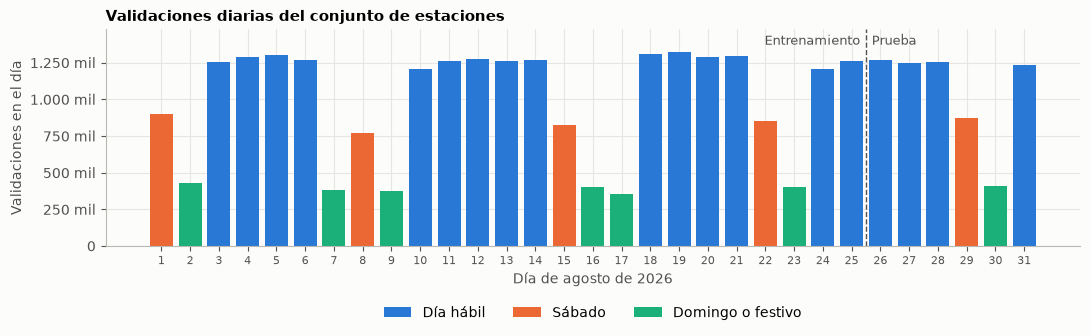

Promedio diario por tipo de día: {'Domingo o festivo': '393,520', 'Día hábil': '1,266,076', 'Sábado': '841,312'}
Un sábado mueve el 66% de un día hábil; un domingo o festivo, el 31%


In [97]:
diario = data.groupby(["fecha", "tipo_dia"])["validaciones"].sum().reset_index()
fig, ax = plt.subplots(figsize=(11, 3.6))
for tipo in COLOR_DIA:
    g = diario[diario["tipo_dia"] == tipo]
    ax.bar(g["fecha"].dt.day, g["validaciones"], color=COLOR_DIA[tipo], label=NOMBRE_DIA[tipo], width=0.8)
ax.axvline(25.5, color=TINTA, linestyle="--", linewidth=1)
ax.text(25.3, diario["validaciones"].max() * 1.04, "Entrenamiento", ha="right", color=TINTA, fontsize=9)
ax.text(25.7, diario["validaciones"].max() * 1.04, "Prueba", ha="left", color=TINTA, fontsize=9)
ax.set_ylim(0, diario["validaciones"].max() * 1.12)
ax.set_xticks(range(1, 32)); ax.tick_params(axis="x", labelsize=8)
ax.set_xlabel("Día de agosto de 2026"); ax.set_ylabel("Validaciones en el día"); ax.yaxis.set_major_formatter(miles)
ax.set_title("Validaciones diarias del conjunto de estaciones")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=3)
plt.tight_layout(); plt.savefig(FIG / "eda_serie_diaria.png", dpi=120); plt.show()

prom = diario.groupby("tipo_dia")["validaciones"].mean()
print("Promedio diario por tipo de día:", {NOMBRE_DIA[k]: f"{x:,.0f}" for k, x in prom.items()})
print(f"Un sábado mueve el {prom['sabado'] / prom['habil']:.0%} de un día hábil; un domingo o festivo, el {prom['domingo_festivo'] / prom['habil']:.0%}")

## 2.4 Perfil a lo largo del día

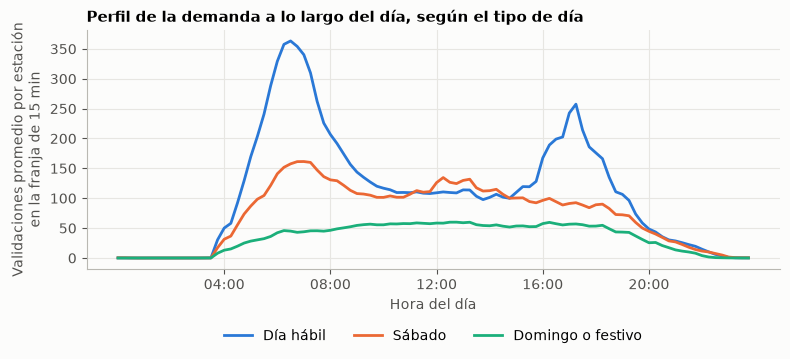

Día hábil: pico de la mañana a las 06:30 (363) y de la tarde a las 17:15 (257); valle del mediodía 109
Correlación lineal entre la hora y las validaciones: -0.17


In [98]:
perfil = data.groupby(["tipo_dia", "hora"])["validaciones"].mean().unstack(0)
fig, ax = plt.subplots(figsize=(8, 3.8))
for tipo in ["habil", "sabado", "domingo_festivo"]:
    ax.plot(perfil.index, perfil[tipo], color=COLOR_DIA[tipo], label=NOMBRE_DIA[tipo])
ax.set_ylabel("Validaciones promedio por estación\nen la franja de 15 min"); eje_horas(ax)
ax.set_title("Perfil de la demanda a lo largo del día, según el tipo de día")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=3)
plt.tight_layout(); plt.savefig(FIG / "eda_perfil_horario.png", dpi=120); plt.show()

h = perfil["habil"]
pico_am, pico_pm = h[h.index < 12].idxmax(), h[h.index >= 12].idxmax()
fmt = lambda x: f"{int(x):02d}:{int(round(x % 1 * 60)):02d}"
print(f"Día hábil: pico de la mañana a las {fmt(pico_am)} ({h[pico_am]:.0f}) y de la tarde a las {fmt(pico_pm)} ({h[pico_pm]:.0f});"
      f" valle del mediodía {h[(h.index >= 10) & (h.index <= 14)].mean():.0f}")
print(f"Correlación lineal entre la hora y las validaciones: {data['hora'].corr(data['validaciones']):.2f}")

## 2.5 Las tres estaciones de estudio

Mazurén: 12,411 validaciones en un día hábil promedio | 60% antes del mediodía | franja más cargada 07:15 (620)
Modelia: 6,902 validaciones en un día hábil promedio | 45% antes del mediodía | franja más cargada 17:15 (305)
Terreros: 27,684 validaciones en un día hábil promedio | 87% antes del mediodía | franja más cargada 06:30 (1828)


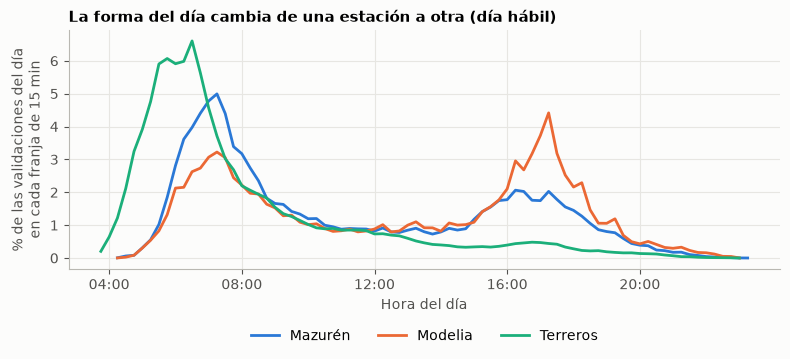


Entre todas las estaciones, la parte del día hábil que entra antes del mediodía va de 12% a 100% (mediana 50%)


In [99]:
habil = data[data["tipo_dia"] == "habil"]
fig, ax = plt.subplots(figsize=(8, 3.8))
for corto, nombre in NOMBRE_EST.items():
    p = habil[habil["estación"] == nombre].groupby("hora")["validaciones"].mean()
    ax.plot(p.index, p / p.sum() * 100, color=COLOR_EST[corto], label=corto)
    print(f"{corto}: {p.sum():,.0f} validaciones en un día hábil promedio | {p[p.index < 12].sum() / p.sum():.0%} antes del mediodía"
          f" | franja más cargada {int(p.idxmax()):02d}:{int(round(p.idxmax() % 1 * 60)):02d} ({p.max():.0f})")
ax.set_ylabel("% de las validaciones del día\nen cada franja de 15 min"); eje_horas(ax)
ax.set_title("La forma del día cambia de una estación a otra (día hábil)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=3)
plt.tight_layout(); plt.savefig(FIG / "eda_estaciones_estudio.png", dpi=120); plt.show()

manana = (habil[habil["hora"] < 12].groupby("estación")["validaciones"].sum() / habil.groupby("estación")["validaciones"].sum())
print(f"\nEntre todas las estaciones, la parte del día hábil que entra antes del mediodía va de {manana.min():.0%} a {manana.max():.0%}"
      f" (mediana {manana.median():.0%})")

## 2.6 Cuánto explica cada variable y correlaciones

Tipo de día                               3.1
Franja horaria                            8.4
Troncal                                   2.7
Estación                                 27.8
Estación y franja juntas                 76.5
Estación, franja y tipo de día juntos    97.5


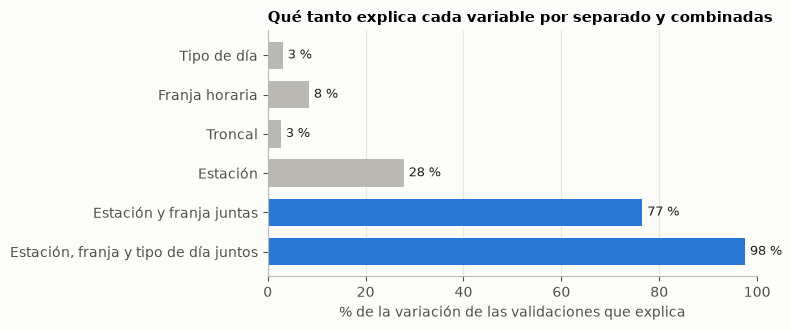

Correlaciones entre las variables numéricas:


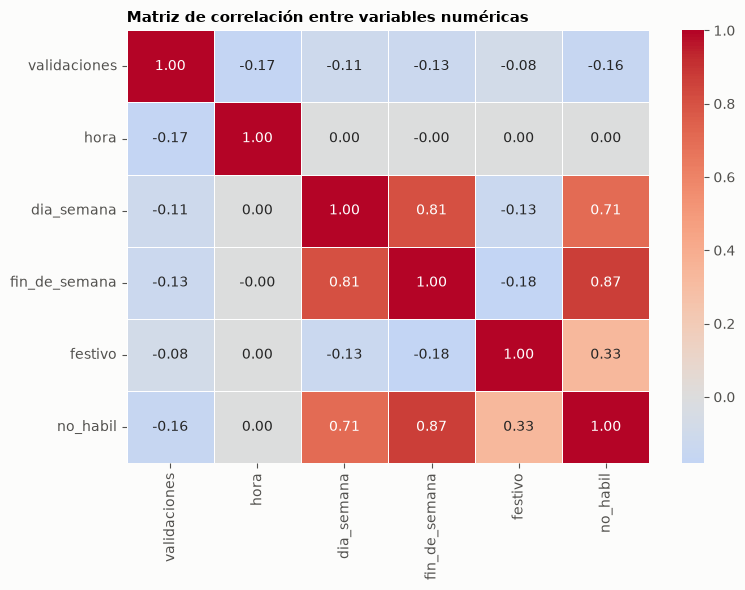

Troncales distintas por estación (máximo): 1 -> la troncal queda determinada por la estación


In [111]:
v = data["validaciones"]
total = ((v - v.mean()) ** 2).sum()

def explica(columnas):                              # parte de la variación que explica el promedio de cada grupo
    return 1 - ((v - data.groupby(columnas)["validaciones"].transform("mean")) ** 2).sum() / total

partes = pd.Series({"Tipo de día": explica(["tipo_dia"]),
                    "Franja horaria": explica(["intervalo"]),
                    "Troncal": explica(["linea"]),
                    "Estación": explica(["estación"]),
                    "Estación y franja juntas": explica(["estación", "intervalo"]),
                    "Estación, franja y tipo de día juntos": explica(["estación", "intervalo", "tipo_dia"])}) * 100
print(partes.round(1).to_string())

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.barh(partes.index[::-1], partes.values[::-1], color=[AZUL, AZUL, GRIS, GRIS, GRIS, GRIS], height=0.7)
for i, x in enumerate(partes.values[::-1]):
    ax.text(x + 1, i, f"{x:.0f} %", va="center", fontsize=9, color=TINTA)
ax.set_xlim(0, 100); ax.grid(axis="y", visible=False)
ax.set_xlabel("% de la variación de las validaciones que explica")
ax.set_title("Qué tanto explica cada variable por separado y combinadas")
plt.tight_layout(); plt.savefig(FIG / "eda_variacion_explicada.png", dpi=120); plt.show()

num = pd.DataFrame({"validaciones": v, "hora": data["hora"], "dia_semana": data["dia_semana"],
                    "fin_de_semana": (data["dia_semana"] >= 5).astype(int),
                    "festivo": data["fecha"].isin(FESTIVOS).astype(int),
                    "no_habil": (data["tipo_dia"] != "habil").astype(int)})
print("Correlaciones entre las variables numéricas:")

corr = num.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Matriz de correlación entre variables numéricas")
plt.tight_layout()
plt.savefig(FIG/"eda_corr.png", dpi=120)
plt.show()

print("Troncales distintas por estación (máximo):", data.groupby("estación")["linea"].nunique().max(),
      "-> la troncal queda determinada por la estación")

## 2.7 Valores atípicos

Registros atípicos: 2,209 (0.8%) | por encima de lo normal: 0.5% | por debajo: 0.2%


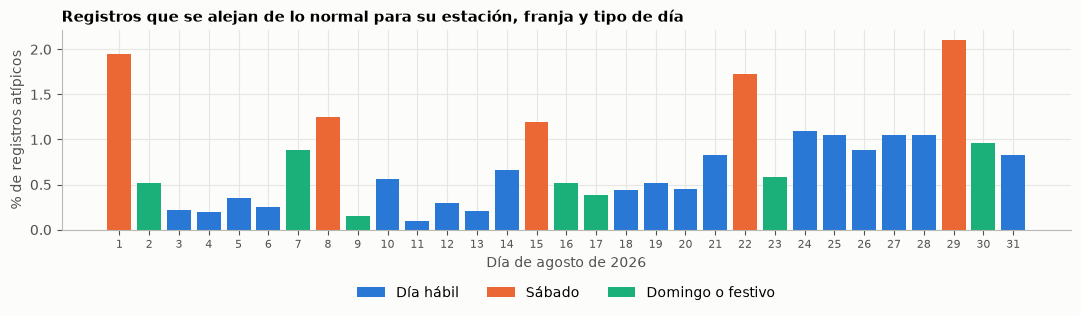

Fechas con más registros atípicos (%):
fecha
2026-08-29 (Sábado)    2.1
2026-08-01 (Sábado)    2.0
2026-08-22 (Sábado)    1.7
2026-08-08 (Sábado)    1.3
2026-08-15 (Sábado)    1.2

Estaciones con más registros atípicos (%):
estación
(09123) Calle 76                11.1
(15002) Los Laureles             9.5
(15003) Islandia                 5.5
(15001) Tibanica - Primavera     4.8
(07106) EL CAMPIN                2.6


In [101]:
grupo = [data["estación"], data["tipo_dia"], data["intervalo"]]
mediana = data.groupby(grupo)["validaciones"].transform("median")
mad = (data["validaciones"] - mediana).abs().groupby(grupo).transform("median")
z = (data["validaciones"] - mediana) / np.maximum(1.4826 * mad, 5)       # desviación robusta, con un piso de 5 validaciones
atipico = z.abs() > 5

print(f"Registros atípicos: {int(atipico.sum()):,} ({atipico.mean():.1%}) | por encima de lo normal: {(z > 5).mean():.1%}"
      f" | por debajo: {(z < -5).mean():.1%}")
por_fecha = atipico.groupby(data["fecha"]).mean() * 100
tipo_fecha = data.groupby("fecha")["tipo_dia"].first()

fig, ax = plt.subplots(figsize=(11, 3.4))
for tipo in COLOR_DIA:
    f = por_fecha[tipo_fecha == tipo]
    ax.bar(f.index.day, f.values, color=COLOR_DIA[tipo], label=NOMBRE_DIA[tipo], width=0.8)
ax.set_xticks(range(1, 32)); ax.tick_params(axis="x", labelsize=8)
ax.set_xlabel("Día de agosto de 2026"); ax.set_ylabel("% de registros atípicos")
ax.set_title("Registros que se alejan de lo normal para su estación, franja y tipo de día")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=3)
plt.tight_layout(); plt.savefig(FIG / "eda_atipicos.png", dpi=120); plt.show()

print("Fechas con más registros atípicos (%):")
print(por_fecha.sort_values(ascending=False).head(5).round(1).rename(lambda d: f"{d.date()} ({NOMBRE_DIA[tipo_fecha[d]]})").to_string())
print("\nEstaciones con más registros atípicos (%):")
print((atipico.groupby(data["estación"]).mean() * 100).sort_values(ascending=False).head(5).round(1).to_string())

## 2.8 Hallazgos y decisiones de limpieza

| Hallazgo | Evidencia | Consecuencia para el modelo |
|---|---|---|
| Datos completos | 294.004 registros, 123 estaciones, 14 troncales, 31 días. 0 nulos, 0 repetidos, 0 negativos | No se imputa ni se elimina nada |
| Muchos ceros, pero fuera de operación | 7,8 % de los registros están en cero; solo 2,3 % entre las 5:00 y las 21:00 | Los ceros son reales (estación sin gente) y se conservan |
| Estaciones con registros incompletos | La mediana es de 79 franjas por estación y día, pero hay días con una sola; una estación tiene apenas 31 registros en el mes | Se conservan, pero su error pesa poco y su predicción es poco confiable |
| Variable muy asimétrica | Media 105,5, mediana 46 y máximo 4.687; asimetría 6,98 (−0,52 en logaritmo). El 10 % de los registros concentra el 52 % de las validaciones | El RMSE lo dominan las estaciones grandes; por eso se reporta también el MAE |
| El tipo de día cambia el nivel | Un sábado mueve el 66 % de un día hábil y un domingo o festivo el 31 % | `tipo_dia` entra como variable |
| La hora no es lineal | En día hábil hay dos picos (06:30 con 363 validaciones y 17:15 con 257) y un valle de 109 al mediodía. La correlación lineal con la hora es −0,17 | Una recta no sirve: se necesitan splines o un efecto por franja |
| Cada estación tiene su propia curva | Antes del mediodía entra el 87 % en Terreros, el 60 % en Mazurén y el 45 % en Modelia; entre todas las estaciones va del 12 % al 100 % | Se cruzan estación y franja |
| Estación y franja explican juntas, no por separado | Estación sola explica el 27,8 % de la variación y franja sola el 8,4 %; juntas el 76,5 % y con tipo de día el 97,5 % | Justifica las columnas cruzadas de la sección 3 |
| Variables redundantes | La troncal queda determinada por la estación (y sola explica 2,7 %). Fin de semana y día no hábil tienen correlación 0,87 | Hay multicolinealidad: es el caso de uso de Ridge |

**Decisiones de limpieza**

| Decisión | Justificación |
|---|---|
| Se excluyen las filas con Fase "Dual" | Quedan 123 estaciones. Deja por fuera estaciones como Alcalá y los portales; es una limitación del alcance |
| Se suman los accesos de una misma estación | La unidad de análisis es la estación, no la puerta |
| Los festivos entre semana (7 y 17 de agosto) se agrupan con los domingos | Su demanda se parece más a la de un domingo que a la de un día hábil |
| No se eliminan ceros ni estaciones con pocos registros | Son observaciones reales |
| La fecha no entra como variable | Con un solo mes no hay tendencia que aprender; su información útil está en `tipo_dia` |

# 3. Modelos

### 3.1 Partición en entrenamiento y prueba

La partición es por fecha: del 1 al 25 de agosto se entrena (237.100 registros, 25 días) y del 26 al 31
se prueba (56.904 registros, 6 días: 4 hábiles, 1 sábado y 1 domingo). Las 123 estaciones están en ambos
lados y cada una tiene el 19,4 % de sus datos en prueba. Así el modelo se evalúa en días que nunca vio.
Los datos de prueba no se usan para ajustar ni para escoger nada; solo para la comparación final.

In [102]:
X = data[["linea", "estación", "intervalo", "fecha", "tipo_dia"]]
y = data["validaciones"]

en_test = data["fecha"].dt.day >= 26          # 26 al 31 de agosto -> prueba; 1 al 25 -> entrenamiento
X_train, X_test = X[~en_test], X[en_test]
y_train, y_test = y[~en_test], y[en_test]

print("Train:", X_train.shape, "| del", X_train["fecha"].min().date(), "al", X_train["fecha"].max().date())
print("Test: ", X_test.shape, "| del", X_test["fecha"].min().date(), "al", X_test["fecha"].max().date())
pct = X_test["estación"].value_counts() / data["estación"].value_counts() * 100
print(f"Estaciones en test: {X_test['estación'].nunique()} de {data['estación'].nunique()}"
      f" | % de cada estación en test: de {pct.min():.1f} a {pct.max():.1f}")
print(X_test.groupby("tipo_dia")["fecha"].nunique())

Train: (237100, 5) | del 2026-08-01 al 2026-08-25
Test:  (56904, 5) | del 2026-08-26 al 2026-08-31
Estaciones en test: 123 de 123 | % de cada estación en test: de 19.4 a 19.4
tipo_dia
domingo_festivo    1
habil              4
sabado             1
Name: fecha, dtype: int64


### 3.2 Preparación de las variables

- **Variable a predecir:** validaciones en la franja de 15 minutos.
- **Categóricas** (`linea`, `estación`, `tipo_dia`): codificación one-hot.
- **Cruces** (`est_franja`, `dia_franja`, `est_dia`): permiten que cada estación tenga su propia curva
  por hora y que esa curva cambie según el tipo de día (hallazgo de la sección 2.6).
- **Hora:** el intervalo como número (05:15 → 5,25), estandarizado. Las columnas one-hot ya están
  todas en la misma escala (0 o 1), así que no se reescalan.
- **Fecha:** no entra directamente.

La preparación va dentro de un *pipeline*: en cada pliegue se ajusta solo con los datos de
entrenamiento de ese pliegue, sin fuga de información. La validación cruzada es de 5 pliegues.

In [103]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, SplineTransformer
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.kernel_approximation import Nystroem
from sklearn.model_selection import KFold, cross_validate, GridSearchCV
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

def a_hora(v):                       # "05:15" -> 5.25
    h, m = str(v).split(":")[:2]
    return int(h[-2:]) + int(m) / 60

def agregar(d):
    d = d.copy()
    d["hora"] = d["intervalo"].map(a_hora)
    d["est_franja"] = d["estación"] + " | " + d["intervalo"].astype(str)     # cada estación con su propia curva
    d["dia_franja"] = d["tipo_dia"] + " | " + d["intervalo"].astype(str)     # la curva cambia según el tipo de día
    d["est_dia"] = d["estación"] + " | " + d["tipo_dia"]                     # cada estación cae distinto el fin de semana
    return d

X_train, X_test = agregar(X_train), agregar(X_test)

CATEGORICAS = ["linea", "estación", "tipo_dia", "est_franja", "dia_franja", "est_dia"]
NUMERICAS = ["hora"]

def preparar():
    return ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAS),
                              ("num", StandardScaler(), NUMERICAS)])

con_splines = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAS),
                                 ("spl", SplineTransformer(), NUMERICAS)])

cv = KFold(n_splits=5, shuffle=True, random_state=42)     # los mismos 5 pliegues para todos los modelos

### 3.3 Los seis modelos con sus parámetros por defecto

Primera comparación: cada método tal como viene, con validación cruzada sobre entrenamiento.
La línea base predice siempre la media y es el piso que todos deben superar.

| Modelo | Qué hace con estos datos |
|---|---|
| Base (media) | Predice el promedio de validaciones para todo |
| OLS | Un coeficiente por estación, franja y tipo de día, y por cada cruce |
| Ridge | Igual que OLS, encogiendo los coeficientes |
| Lasso | Igual que OLS, pudiendo llevar coeficientes a cero |
| Splines | Agrega una curva suave sobre la hora |
| Kernel (RBF) | Parecido entre registros; aproximado con Nyström porque el kernel exacto necesitaría una matriz de 237.100 × 237.100 (unos 450 GB) |

**Lectura.** OLS, Ridge y Splines bajan el RMSE de 216,2 (base) a 86,9, con R² de 0,84. Lasso (181,1) y
el kernel (201,0) quedan lejos con sus valores por defecto; la búsqueda en grilla dice si es por el
método o por el hiperparámetro unicamente de los finalistas.

## 3.3.b Sin cruces

In [104]:
modelos = {"Base (media)": make_pipeline(preparar(), DummyRegressor(strategy="mean")),
           "OLS":          make_pipeline(preparar(), LinearRegression()),
           "Ridge":        make_pipeline(preparar(), Ridge(alpha=1.0)),
           "Lasso":        make_pipeline(preparar(), Lasso(alpha=1.0)),
           "Splines":      make_pipeline(con_splines, LinearRegression()),
           "Kernel (RBF)": make_pipeline(preparar(), Nystroem(kernel="rbf", gamma=None, n_components=100,
                                                              random_state=2026), Ridge(alpha=1.0))}
filas = {}
for nombre, m in modelos.items():
    r = cross_validate(m, X_train, y_train, cv=cv, n_jobs=-1,
                       scoring=("neg_mean_absolute_error", "neg_root_mean_squared_error", "r2"))
    filas[nombre] = {"MAE": -r["test_neg_mean_absolute_error"].mean(),
                     "RMSE": -r["test_neg_root_mean_squared_error"].mean(),
                     "RMSE (desv. entre pliegues)": r["test_neg_root_mean_squared_error"].std(),
                     "R2": r["test_r2"].mean()}
tabla_cv = pd.DataFrame(filas).T.sort_values("RMSE")
display(tabla_cv.round(3))

,MAE,RMSE,RMSE (desv. entre pliegues),R2
Ridge,41.806,86.853,1.029,0.839
OLS,41.331,86.867,1.096,0.839
Splines,41.331,86.867,1.096,0.839
Lasso,85.101,181.106,2.393,0.298
Kernel (RBF),94.517,200.972,3.142,0.136
Base (media),104.648,216.219,2.379,-0.000


In [105]:
SIMPLES = ["linea", "estación", "tipo_dia"]
codificar = lambda: ("cat", OneHotEncoder(handle_unknown="ignore"), SIMPLES)
sin_cruces = {"OLS sin cruces":     make_pipeline(ColumnTransformer([codificar(), ("num", StandardScaler(), NUMERICAS)]), LinearRegression()),
              "Splines sin cruces": make_pipeline(ColumnTransformer([codificar(), ("spl", SplineTransformer(), NUMERICAS)]), LinearRegression())}
filas = {}
for nombre, m in sin_cruces.items():
    r = cross_validate(m, X_train, y_train, cv=cv, n_jobs=-1, scoring=("neg_root_mean_squared_error", "r2"))
    filas[nombre] = {"RMSE": -r["test_neg_root_mean_squared_error"].mean(), "R2": r["test_r2"].mean()}
efecto = pd.concat([pd.DataFrame(filas).T,
                    tabla_cv.loc[["OLS", "Splines"], ["RMSE", "R2"]].rename(index=lambda s: s + " con cruces")])
display(efecto.round(3))

,RMSE,R2
OLS sin cruces,176.360,0.335
Splines sin cruces,169.001,0.389
OLS con cruces,86.867,0.839
Splines con cruces,86.867,0.839


### 3.4 Selección de hiperparámetros

Cada método pasa por búsqueda en grilla con los mismos 5 pliegues y solo con datos de entrenamiento.
La tabla muestra qué se probó, qué valor quedó y si cayó en el borde del rango. Los tres mejores,
ya ajustados, son los finalistas.

OLS: listo en 0.1 min
Ridge: listo en 0.3 min
Splines: listo en 0.6 min


,RMSE en CV (por defecto),RMSE en CV (ajustado),Desv. entre pliegues,Rango probado,Valor elegido,¿En el borde?
Ridge,86.853,86.841,1.088,"alpha: [0.01, 0.1, 1, 10, 100, 1000]",alpha = 0.1,no
OLS,86.867,86.867,1.096,no tiene,no tiene,no
Splines,86.867,86.867,1.096,"n_knots: [5, 10, 20, 40, 60, 80]",n_knots = 10,no


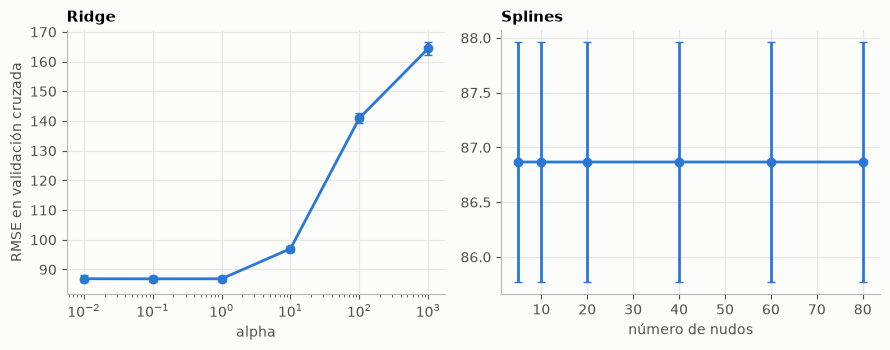

Finalistas: ['Ridge', 'OLS', 'Splines'] | Mejor por validación cruzada: Ridge


In [106]:
GRILLAS = {"OLS":     {},
           "Ridge":   {"ridge__alpha": [0.01, 0.1, 1, 10, 100, 1000]},
           "Splines": {"columntransformer__spl__n_knots": [5, 10, 20, 40, 60, 80]}}

busquedas = {}
for nombre, grilla in GRILLAS.items():
    t0 = time.time()
    busquedas[nombre] = GridSearchCV(modelos[nombre], grilla, cv=cv, n_jobs=-1,
                                     scoring="neg_root_mean_squared_error").fit(X_train, y_train)
    print(f"{nombre}: listo en {(time.time() - t0) / 60:.1f} min")

corto = lambda k: k.split("__")[-1]
filas = {}
for nombre, b in busquedas.items():
    borde = [corto(k) for k, v in b.best_params_.items()
             if len(GRILLAS[nombre][k]) > 1 and v in (GRILLAS[nombre][k][0], GRILLAS[nombre][k][-1])]
    filas[nombre] = {"RMSE en CV (por defecto)": round(tabla_cv.loc[nombre, "RMSE"], 3),
                     "RMSE en CV (ajustado)": round(-b.best_score_, 3),
                     "Desv. entre pliegues": round(b.cv_results_["std_test_score"][b.best_index_], 3),
                     "Rango probado": "; ".join(f"{corto(k)}: {v}" for k, v in GRILLAS[nombre].items()) or "no tiene",
                     "Valor elegido": ", ".join(f"{corto(k)} = {v}" for k, v in b.best_params_.items()) or "no tiene",
                     "¿En el borde?": ", ".join(borde) or "no"}
tabla_hiper = pd.DataFrame(filas).T.sort_values("RMSE en CV (ajustado)")
display(tabla_hiper)

# Curvas de validación: error en CV según el hiperparámetro
fig, ejes = plt.subplots(1, 2, figsize=(9, 3.6))
for ax, (nombre, clave, etiqueta) in zip(ejes, [("Ridge", "ridge__alpha", "alpha"),
                                                 ("Splines", "columntransformer__spl__n_knots", "número de nudos")]):
    r = pd.DataFrame(busquedas[nombre].cv_results_)
    ax.errorbar(r["param_" + clave].astype(float), -r["mean_test_score"], yerr=r["std_test_score"],
                marker="o", color=AZUL, capsize=3)
    if etiqueta == "alpha": ax.set_xscale("log")
    ax.set_title(nombre); ax.set_xlabel(etiqueta)
ejes[0].set_ylabel("RMSE en validación cruzada")
plt.tight_layout(); plt.savefig(FIG / "curvas_validacion.png", dpi=120); plt.show()

# Finalistas: los tres modelos de menor error en la validación cruzada
finalistas = tabla_hiper.index.tolist()
ajustados = {n: busquedas[n].best_estimator_ for n in finalistas}
comparacion = tabla_hiper.loc[finalistas]
mejor = finalistas[0]
print("Finalistas:", finalistas, "| Mejor por validación cruzada:", mejor)

### 3.5 Matriz de aplicabilidad

| Método | ¿Aporta? | RMSE en CV | Justificación |
|---|---|---|---|
| Base (media) | Referencia | 216,2 ± 2,4 | Piso de comparación |
| OLS | Sí | 86,87 ± 1,10 | Modelo de referencia. Con los cruces de estación, franja y tipo de día baja el error un 60 % frente a la base (R² 0,84) |
| Ridge | Sí, por estabilidad | 86,84 ± 1,03 (alpha = 0,1) | En error empata con OLS (0,03 de diferencia frente a 1,0 de variación entre pliegues). Aporta porque las columnas son redundantes (la troncal la determina la estación y los cruces contienen a los efectos sueltos): OLS no tiene solución única y Ridge sí |
| Lasso | No | 181,1 ± 2,4 (alpha = 1) | Lasso sirve para descartar variables irrelevantes, y aquí no las hay: cada cruce estación-franja lleva información. Al penalizar, apaga esos cruces y vuelve al modelo sin interacciones |
| Splines | No | 86,87 ± 1,10 | Da exactamente lo mismo que OLS con cualquier número de nudos (de 5 a 80). Con un coeficiente por estación y franja, la curva horaria ya está descrita por completo. Sin los cruces sí aportaba (celda 3.3b) |
| Kernel (RBF) | No | 201,0 ± 3,1 | El kernel exacto no cabe en memoria (237.100 × 237.100). La aproximación de Nyström resume los datos con unos cientos de puntos de referencia y no alcanza a cubrir las cerca de 9.500 combinaciones de estación y franja |

**Hiperparámetros**

| Método | Hiperparámetro | Rango probado | Valor elegido | Justificación |
|---|---|---|---|---|
| OLS | no tiene | — | — | — |
| Ridge | alpha | 0,01 a 1000 (6 valores) | 0,1 | Mínimo de RMSE en CV; no está en el borde |
| Splines | número de nudos | 5 a 80 (6 valores) | 20 | El error no cambia con los nudos (86,8668 a 86,8669): la elección es indiferente |



## 4. Comparación final en los datos de prueba

### 4.1 Error de los finalistas en prueba

Es la primera y única vez que se usan los datos de prueba. Los errores están en validaciones por
franja de 15 minutos.

In [107]:
en_prueba = {"Base (media)": modelos["Base (media)"].fit(X_train, y_train), **{n: ajustados[n] for n in comparacion.index}}
pred = {nombre: m.predict(X_test) for nombre, m in en_prueba.items()}

tabla_test = pd.DataFrame({nombre: {"MAE": mean_absolute_error(y_test, p),
                                    "RMSE": root_mean_squared_error(y_test, p),
                                    "R2": r2_score(y_test, p)} for nombre, p in pred.items()}).T
tabla_test["Mejora en MAE frente a la base"] = (1 - tabla_test["MAE"] / tabla_test.loc["Base (media)", "MAE"]).map("{:.0%}".format)
display(tabla_test.round(3))

,MAE,RMSE,R2,Mejora en MAE frente a la base
Base (media),105.140,220.670,-0.001,0%
Ridge,38.801,80.397,0.867,63%
OLS,38.729,80.347,0.867,63%
Splines,38.729,80.347,0.867,63%


### 4.2 Bootstrap: ¿la diferencia entre finalistas es real?

Se remuestrean 1.000 veces los días de los datos de prueba (días completos, porque las franjas de un
mismo día se parecen entre sí) y se recalcula el error de cada modelo. Si el intervalo del 95 % de la
diferencia frente al mejor no incluye el 0, la ventaja es real.

In [108]:
B = 1000
rng = np.random.default_rng(42)
dia = pd.to_datetime(X_test["fecha"]).dt.date.to_numpy()
dias = np.unique(dia)
muestras = rng.integers(0, len(dias), size=(B, len(dias)))          # los mismos días para todos los modelos

def por_dia(valores):                                               # suma de cada día, en el orden de `dias`
    return pd.Series(valores).groupby(dia).sum().reindex(dias).to_numpy()

n = por_dia(np.ones(len(X_test)))
boot = {}
for nombre in comparacion.index:                                    # del mejor al peor por CV
    e = y_test.to_numpy() - pred[nombre]
    abs_dia, cuad_dia = por_dia(np.abs(e)), por_dia(e ** 2)
    boot[nombre] = {"MAE": abs_dia[muestras].sum(1) / n[muestras].sum(1),
                    "RMSE": np.sqrt(cuad_dia[muestras].sum(1) / n[muestras].sum(1))}

def intervalo(v):
    return f"{v.mean():.2f}  [{np.percentile(v, 2.5):.2f}, {np.percentile(v, 97.5):.2f}]"

display(pd.DataFrame({k: {met: intervalo(v) for met, v in d.items()} for k, d in boot.items()}).T
        .rename(columns=lambda c: c + " en prueba, IC 95 %"))

for otro in comparacion.index[1:]:
    for met in ("MAE", "RMSE"):
        dif = boot[otro][met] - boot[mejor][met]
        lo, hi = np.percentile(dif, [2.5, 97.5])
        print(f"{met}: {otro} − {mejor} = {dif.mean():.2f}  [{lo:.2f}, {hi:.2f}]  ->",
              "diferencia real" if lo > 0 or hi < 0 else "no se distinguen (el intervalo incluye 0)")

,"MAE en prueba, IC 95 %","RMSE en prueba, IC 95 %"
Ridge,"38.75 [34.23, 46.81]","79.80 [67.06, 98.26]"
OLS,"38.67 [34.12, 46.83]","79.74 [67.03, 98.43]"
Splines,"38.67 [34.12, 46.83]","79.74 [67.03, 98.43]"


MAE: OLS − Ridge = -0.07  [-0.22, 0.12]  -> no se distinguen (el intervalo incluye 0)
RMSE: OLS − Ridge = -0.07  [-0.37, 0.29]  -> no se distinguen (el intervalo incluye 0)
MAE: Splines − Ridge = -0.07  [-0.22, 0.12]  -> no se distinguen (el intervalo incluye 0)
RMSE: Splines − Ridge = -0.07  [-0.37, 0.29]  -> no se distinguen (el intervalo incluye 0)


### 4.3 Comportamiento en Mazurén, Modelia y Terreros

El mejor modelo frente a los datos reales en dos lunes hábiles: arriba uno de entrenamiento
(24 de agosto) y abajo el de prueba (31 de agosto), que el modelo nunca vio. Los puntos son los datos
reales y la línea es la predicción. La tabla compara el error de cada estación en entrenamiento y en
prueba. La celda siguiente repite el ejercicio con dos sábados (22 y 29 de agosto).

Lunes de entrenamiento: 2026-08-24 | Lunes de prueba: 2026-08-31


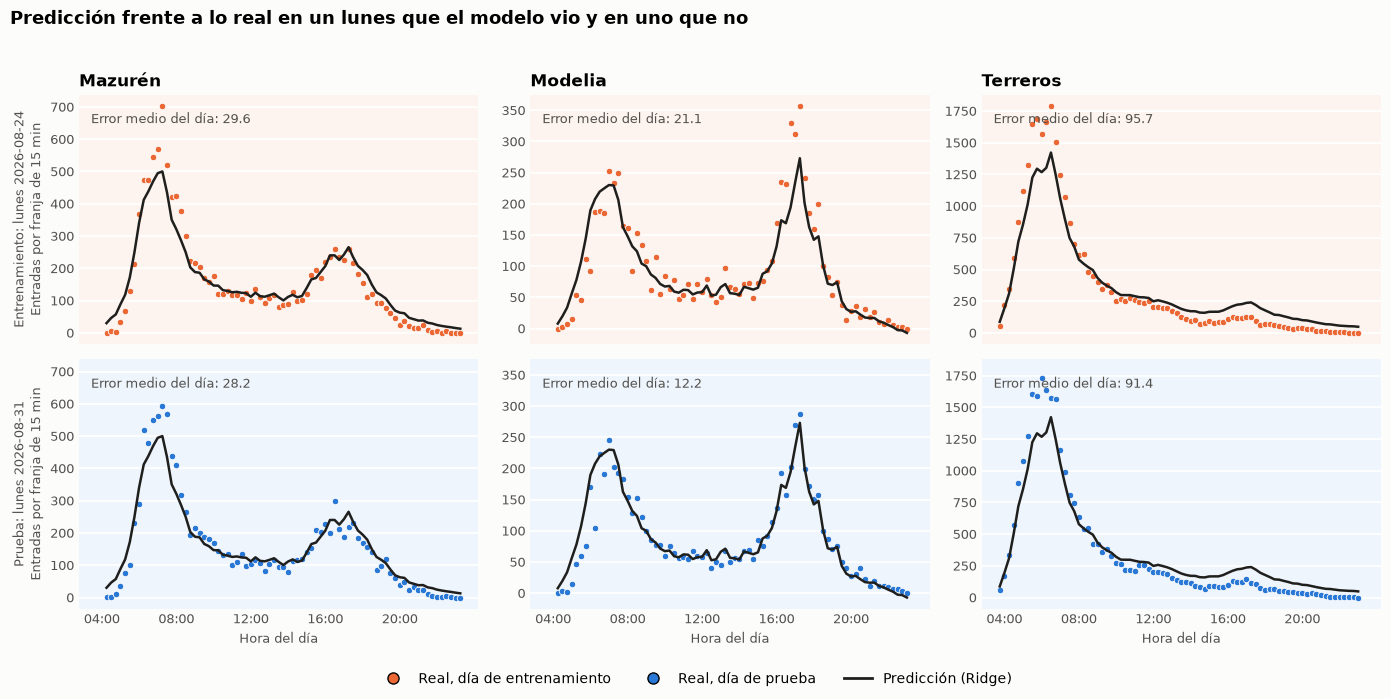

Modelo: Ridge | Error por estación, entrenamiento (1 al 25) contra prueba (26 al 31):


,Entradas promedio (prueba),MAE entrenamiento,MAE prueba,RMSE prueba,MAE prueba / promedio
Mazurén,125.82,31.37,31.14,44.33,0.25
Modelia,71.44,18.45,16.87,24.81,0.24
Terreros,294.04,114.30,106.80,155.66,0.36


In [109]:
import unicodedata
from matplotlib.lines import Line2D

def sin_tilde(s):                                   # "MAZURÉN" -> "mazuren"
    return unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode().lower()

modelo = ajustados[mejor]
ESTUDIO = {"Mazurén": "mazuren", "Modelia": "modelia", "Terreros": "terreros"}     # nombre -> texto a buscar (sin tilde)
est_norm = data["estación"].map(sin_tilde)

# Un lunes hábil de entrenamiento (1 al 25, al azar) y el lunes hábil de prueba (26 al 31)
fechas = pd.to_datetime(data["fecha"])
dias_lunes = pd.to_datetime(data.loc[(fechas.dt.dayofweek == 0) & (data["tipo_dia"] == "habil"), "fecha"]).drop_duplicates()
LUNES_TRAIN = dias_lunes[dias_lunes.dt.day <= 25].sample(1, random_state=2026).iloc[0]
LUNES_TEST = dias_lunes[dias_lunes.dt.day >= 26].iloc[0]
print("Lunes de entrenamiento:", LUNES_TRAIN.date(), "| Lunes de prueba:", LUNES_TEST.date())

NARANJA, AZUL, TINTA = "#eb6834", "#2a78d6", "#1f1f1d"
FILAS = [(LUNES_TRAIN, "Entrenamiento", NARANJA, "#fdf4ef"),
         (LUNES_TEST,  "Prueba",        AZUL,    "#eff5fd")]

fig, ejes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey="col")
for fila, (dia, rol, color, fondo) in enumerate(FILAS):
    for col, (est, buscar) in enumerate(ESTUDIO.items()):
        ax = ejes[fila, col]
        nombre = data.loc[est_norm.str.contains(buscar), "estación"].iloc[0]
        d = data[(data["estación"] == nombre) & (fechas == dia)].copy()
        d = agregar(d).sort_values("hora")
        d["pred"] = modelo.predict(d[X_train.columns])
        mae_dia = mean_absolute_error(d.validaciones, d.pred)

        ax.set_facecolor(fondo)
        ax.grid(axis="y", color="white", linewidth=1.2)
        ax.grid(axis="x", visible=False)
        ax.set_axisbelow(True)
        ax.scatter(d.hora, d.validaciones, s=22, color=color, edgecolor="white", linewidth=0.6, zorder=3)
        ax.plot(d.hora, d.pred, color=TINTA, linewidth=1.8, zorder=4)
        ax.text(0.03, 0.93, f"Error medio del día: {mae_dia:.1f}", transform=ax.transAxes,
                ha="left", va="top", fontsize=9.5, color="#52514e")
        for lado in ("top", "right", "left", "bottom"):
            ax.spines[lado].set_visible(False)
        ax.tick_params(length=0, labelsize=9)
        if fila == 0:
            ax.set_title(est, loc="left", fontweight="bold", fontsize=12)
        if fila == 1:
            ax.set_xticks(range(4, 24, 4)); ax.set_xticklabels([f"{h:02d}:00" for h in range(4, 24, 4)])
            ax.set_xlabel("Hora del día", fontsize=9.5)
    ejes[fila, 0].set_ylabel(f"{rol}: lunes {dia.date()}\nEntradas por franja de 15 min", fontsize=9.5)

leyenda = [Line2D([0], [0], marker="o", color="none", markerfacecolor=NARANJA, markersize=8, label="Real, día de entrenamiento"),
           Line2D([0], [0], marker="o", color="none", markerfacecolor=AZUL, markersize=8, label="Real, día de prueba"),
           Line2D([0], [0], color=TINTA, linewidth=2, label=f"Predicción ({mejor})")]
fig.legend(handles=leyenda, loc="lower center", ncol=3, frameon=False, fontsize=10)
fig.suptitle("Predicción frente a lo real en un lunes que el modelo vio y en uno que no", x=0.01, ha="left",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=(0, 0.05, 1, 0.96)); plt.show()

errores = {}
for est, buscar in ESTUDIO.items():                                 # error de cada estación en todos sus datos
    nombre = data.loc[est_norm.str.contains(buscar), "estación"].iloc[0]
    tr, te = X_train[X_train["estación"] == nombre], X_test[X_test["estación"] == nombre]
    errores[est] = {"Entradas promedio (prueba)": y_test[te.index].mean(),
                    "MAE entrenamiento": mean_absolute_error(y_train[tr.index], modelo.predict(tr)),
                    "MAE prueba": mean_absolute_error(y_test[te.index], modelo.predict(te)),
                    "RMSE prueba": root_mean_squared_error(y_test[te.index], modelo.predict(te))}
errores = pd.DataFrame(errores).T
errores["MAE prueba / promedio"] = errores["MAE prueba"] / errores["Entradas promedio (prueba)"]
print("Modelo:", mejor, "| Error por estación, entrenamiento (1 al 25) contra prueba (26 al 31):")
display(errores.round(2))

## 4.4 Los mismos modelos en un sábado

Sábado de entrenamiento: 2026-08-22 | Sábado de prueba: 2026-08-29


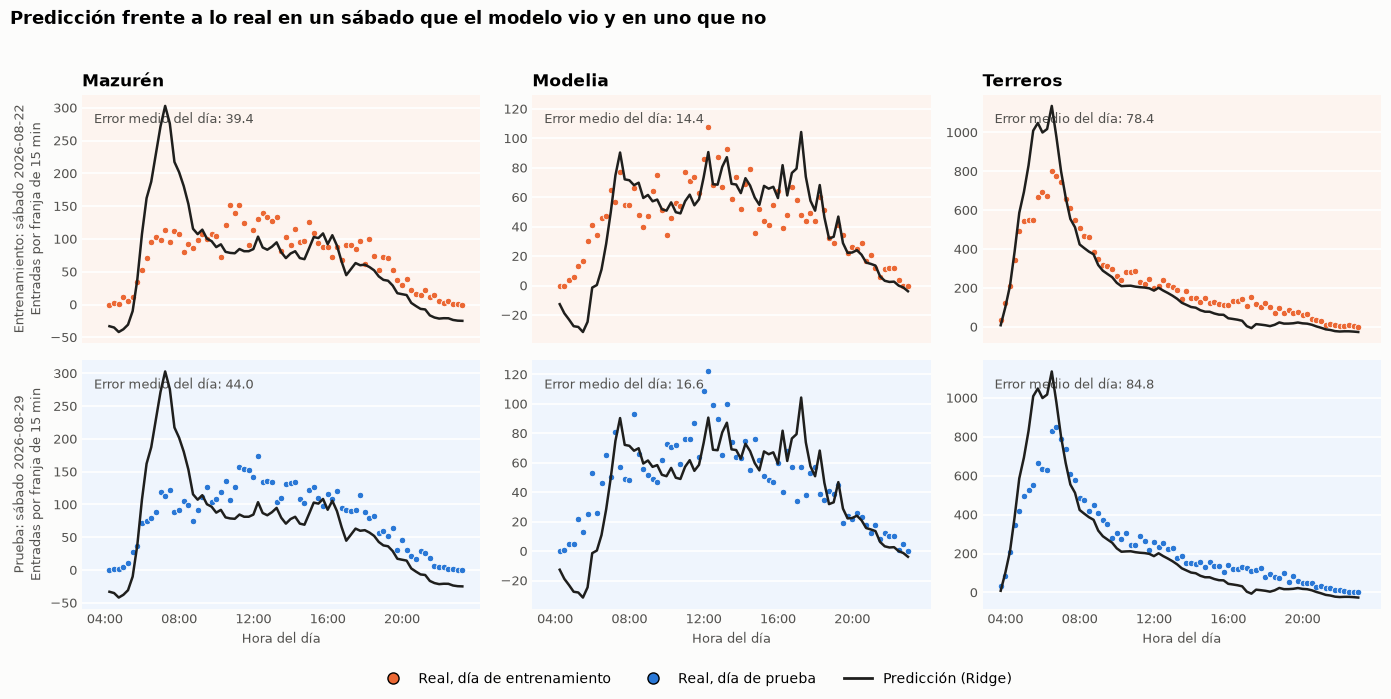

In [110]:
fechas = pd.to_datetime(data["fecha"])
dias_sab = pd.to_datetime(data.loc[(fechas.dt.dayofweek == 5) & (data["tipo_dia"] == "sabado"), "fecha"]).drop_duplicates()
SAB_TRAIN = dias_sab[dias_sab.dt.day <= 25].sample(1, random_state=2026).iloc[0]
SAB_TEST = dias_sab[dias_sab.dt.day >= 26].iloc[0]
print("Sábado de entrenamiento:", SAB_TRAIN.date(), "| Sábado de prueba:", SAB_TEST.date())

FILAS = [(SAB_TRAIN, "Entrenamiento", NARANJA, "#fdf4ef"),
         (SAB_TEST,  "Prueba",        AZUL,    "#eff5fd")]

fig, ejes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey="col")
for fila, (dia, rol, color, fondo) in enumerate(FILAS):
    for col, (est, buscar) in enumerate(ESTUDIO.items()):
        ax = ejes[fila, col]
        nombre = data.loc[est_norm.str.contains(buscar), "estación"].iloc[0]
        d = data[(data["estación"] == nombre) & (fechas == dia)].copy()
        d = agregar(d).sort_values("hora")
        d["pred"] = modelo.predict(d[X_train.columns])
        mae_dia = mean_absolute_error(d.validaciones, d.pred)

        ax.set_facecolor(fondo)
        ax.grid(axis="y", color="white", linewidth=1.2)
        ax.grid(axis="x", visible=False)
        ax.set_axisbelow(True)
        ax.scatter(d.hora, d.validaciones, s=22, color=color, edgecolor="white", linewidth=0.6, zorder=3)
        ax.plot(d.hora, d.pred, color=TINTA, linewidth=1.8, zorder=4)
        ax.text(0.03, 0.93, f"Error medio del día: {mae_dia:.1f}", transform=ax.transAxes,
                ha="left", va="top", fontsize=9.5, color="#52514e")
        for lado in ("top", "right", "left", "bottom"):
            ax.spines[lado].set_visible(False)
        ax.tick_params(length=0, labelsize=9)
        if fila == 0:
            ax.set_title(est, loc="left", fontweight="bold", fontsize=12)
        if fila == 1:
            ax.set_xticks(range(4, 24, 4)); ax.set_xticklabels([f"{h:02d}:00" for h in range(4, 24, 4)])
            ax.set_xlabel("Hora del día", fontsize=9.5)
    ejes[fila, 0].set_ylabel(f"{rol}: sábado {dia.date()}\nEntradas por franja de 15 min", fontsize=9.5)

leyenda = [Line2D([0], [0], marker="o", color="none", markerfacecolor=NARANJA, markersize=8, label="Real, día de entrenamiento"),
           Line2D([0], [0], marker="o", color="none", markerfacecolor=AZUL, markersize=8, label="Real, día de prueba"),
           Line2D([0], [0], color=TINTA, linewidth=2, label=f"Predicción ({mejor})")]
fig.legend(handles=leyenda, loc="lower center", ncol=3, frameon=False, fontsize=10)
fig.suptitle("Predicción frente a lo real en un sábado que el modelo vio y en uno que no", x=0.01, ha="left",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=(0, 0.05, 1, 0.96)); plt.show()

### 4.5 Decisión

- **Modelo escogido:** Ridge con alpha = 0,1, sobre las variables estación, troncal, tipo de día y sus cruces con la franja horaria.
- **Error en prueba:** MAE de 38,8 validaciones por franja de 15 minutos (IC 95 %: 34,2 a 46,8), RMSE de 80,4 y R² de 0,87.
  Es un 63 % menos que la línea base (MAE 105,1).
- **Frente a los otros finalistas:** empate. La diferencia de MAE con OLS es de −0,08 [−0,22; 0,11] y con Splines
  la misma, porque Splines y OLS dan predicciones idénticas. Los intervalos incluyen el cero.
- **Por qué Ridge y no OLS:** como el error es el mismo, se decide por contexto. Las columnas son redundantes,
  así que OLS no tiene coeficientes únicos; Ridge sí, con el mismo costo de cómputo y un solo hiperparámetro
  que no quedó en el borde.
- **Por estación (MAE en prueba):** Mazurén 31,2 (25 % de su demanda promedio), Modelia 16,9 (24 %) y
  Terreros 106,8 (36 %). Donde más falla es en Terreros, la más grande y la más concentrada en la mañana.
- **No hay sobreajuste:** el error en prueba (RMSE 80,4) no supera al de validación cruzada (86,8), y por
  estación el error en entrenamiento y en prueba es casi igual (Mazurén 31,4 y 31,2).
- **Qué es el modelo en la práctica:** el perfil promedio de cada estación en cada franja, corregido por
  el tipo de día. Sirve para planear un día normal, no para anticipar un día atípico.

**Limitaciones**
- Un solo mes de datos y solo seis días de prueba (un sábado y un domingo): los intervalos son anchos.
- Los dos festivos entre semana están en entrenamiento; el modelo no se probó en un festivo.
- No usa la oferta de buses ni eventos (marchas, cierres, lluvia).
- Se excluyeron las filas con Fase "Dual", así que no cubre estaciones como Alcalá ni los portales.
- El error absoluto crece con el tamaño de la estación; modelar el logaritmo de las validaciones es una mejora posible.